# TaaSim — NYC Taxi ETL & Demand Forecasting Model

**Dataset**: NYC TLC Yellow Taxi Trip Records (January–March 2023)  
**Volume**: ~9.38M trips across 3 months  
**Purpose**: Batch ETL pipeline + GBT demand forecasting model  

## Notebook Objectives

### Part 1 — NYC ETL Pipeline
1. Load NYC TLC Parquet files and inspect schema drift across months
2. Data quality assessment: nulls, outliers, distributions
3. Clean and normalize records
4. Temporal feature extraction
5. Per-zone per-hour demand aggregation
6. Hourly demand curve and top pickup zones

### Part 2 — ML Demand Forecasting (Porto-based)
7. Feature matrix exploration (from curated Porto ETL)
8. Train/test temporal split
9. GBT model training (Spark MLlib)
10. Evaluation: RMSE, MAE, R² vs naive 7-day-lag baseline
11. Feature importance analysis
12. Actual vs predicted visualization

---

> **Architecture**: This notebook is a documentation companion to the production Spark scripts  
> `spark/etl_nyc.py`, `spark/feature_engineering.py`, and `spark/train_demand_model.py`.  
> All outputs are already computed and stored in MinIO (`curated/` and `mldata/` buckets).

In [1]:
# Cell 1: Imports and Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
from datetime import datetime
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

COLORS = {
    "primary": "#2196F3",
    "secondary": "#FF9800",
    "success": "#4CAF50",
    "danger": "#F44336",
    "dark": "#37474F",
    "light": "#ECEFF1",
}

print("Libraries loaded.")
print(f"Pandas {pd.__version__}, NumPy {np.__version__}")

Libraries loaded.
Pandas 3.0.2, NumPy 2.4.4


---

# Part 1 — NYC TLC ETL Pipeline

The NYC Taxi & Limousine Commission (TLC) publishes monthly trip records for yellow taxis.  
We process 3 months (Jan–Mar 2023, ~9.38M trips) to produce per-zone per-hour demand aggregates.

**Pipeline**: `s3a://raw/nyc-tlc/*.parquet` → Clean → Aggregate → `s3a://curated/nyc-demand/`

## 1. Load NYC TLC Data and Schema Inspection

In [2]:
# Cell 2: Load 3 months of NYC TLC Parquet
data_dir = "../data/nyc-tlc"
files = [
    "yellow_tripdata_2023-01.parquet",
    "yellow_tripdata_2023-02.parquet",
    "yellow_tripdata_2023-03.parquet",
]

dfs = {}
for f in files:
    path = os.path.join(data_dir, f)
    month = f.split("_")[-1].replace(".parquet", "")
    dfs[month] = pd.read_parquet(path)
    print(f"{month}: {len(dfs[month]):>12,} rows, {len(dfs[month].columns)} cols")

total_raw = sum(len(d) for d in dfs.values())
print(f"\nTotal raw rows: {total_raw:,}")

2023-01:    3,066,766 rows, 19 cols
2023-02:    2,913,955 rows, 19 cols
2023-03:    3,403,766 rows, 19 cols

Total raw rows: 9,384,487


In [3]:
# Cell 3: Schema comparison across months — detecting schema drift
print("=" * 70)
print("  SCHEMA DRIFT ANALYSIS")
print("=" * 70)

for month, df in dfs.items():
    print(f"\n--- {month} ---")
    for col in df.columns:
        print(f"  {col:30s}  {str(df[col].dtype):15s}")

# Highlight differences
print("\n" + "=" * 70)
print("  DETECTED DRIFT")
print("=" * 70)
months = list(dfs.keys())
ref = dfs[months[0]]
for month in months[1:]:
    other = dfs[month]
    # Column name differences
    extra = set(other.columns) - set(ref.columns)
    missing = set(ref.columns) - set(other.columns)
    if extra or missing:
        print(f"\n{month} vs {months[0]}:")
        if extra:
            print(f"  Extra columns: {extra}")
        if missing:
            print(f"  Missing columns: {missing}")
    # Dtype differences for common cols
    for col in set(ref.columns) & set(other.columns):
        if ref[col].dtype != other[col].dtype:
            print(f"  {col}: {ref[col].dtype} -> {other[col].dtype}")

  SCHEMA DRIFT ANALYSIS

--- 2023-01 ---
  VendorID                        int64          
  tpep_pickup_datetime            datetime64[us] 
  tpep_dropoff_datetime           datetime64[us] 
  passenger_count                 float64        
  trip_distance                   float64        
  RatecodeID                      float64        
  store_and_fwd_flag              str            
  PULocationID                    int64          
  DOLocationID                    int64          
  payment_type                    int64          
  fare_amount                     float64        
  extra                           float64        
  mta_tax                         float64        
  tip_amount                      float64        
  tolls_amount                    float64        
  improvement_surcharge           float64        
  total_amount                    float64        
  congestion_surcharge            float64        
  airport_fee                     float64        

--- 2023

In [4]:
# Cell 4: Normalize and merge all months
# Mirrors spark/etl_nyc.py: read_and_normalize()
def normalize_df(df):
    """Handle schema drift: rename Airport_fee, cast types."""
    df = df.copy()
    if "Airport_fee" in df.columns:
        df = df.rename(columns={"Airport_fee": "airport_fee"})
    cast_map = {
        "VendorID": "float64",
        "passenger_count": "float64",
        "RatecodeID": "float64",
        "PULocationID": "float64",
        "DOLocationID": "float64",
    }
    for col, dtype in cast_map.items():
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce").astype(dtype)
    return df

all_dfs = [normalize_df(df) for df in dfs.values()]
raw = pd.concat(all_dfs, ignore_index=True)
print(f"Merged dataset: {len(raw):,} rows x {len(raw.columns)} columns")
print(f"Memory: {raw.memory_usage(deep=True).sum() / 1e9:.2f} GB")
raw.head(3)

Merged dataset: 9,384,487 rows x 19 columns
Memory: 1.44 GB


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee
0,2.0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,1.0,N,161.0,141.0,2,9.3,1.0,0.5,0.0,0.0,1.0,14.3,2.5,0.0
1,2.0,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,1.0,N,43.0,237.0,1,7.9,1.0,0.5,4.0,0.0,1.0,16.9,2.5,0.0
2,2.0,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,1.0,N,48.0,238.0,1,14.9,1.0,0.5,15.0,0.0,1.0,34.9,2.5,0.0


## 2. Data Quality Assessment

In [5]:
# Cell 5: Null analysis
print("=" * 60)
print("  NULL VALUE ANALYSIS")
print("=" * 60)

null_counts = raw.isnull().sum()
null_pct = (null_counts / len(raw) * 100).round(2)

null_df = pd.DataFrame({"nulls": null_counts, "pct": null_pct})
null_df = null_df[null_df["nulls"] > 0].sort_values("nulls", ascending=False)

if len(null_df) > 0:
    print(null_df.to_string())
else:
    print("No null values found.")

print(f"\nTotal rows with any null: {raw.isnull().any(axis=1).sum():,}")

  NULL VALUE ANALYSIS
                       nulls   pct
passenger_count       236179  2.52
RatecodeID            236179  2.52
store_and_fwd_flag    236179  2.52
congestion_surcharge  236179  2.52
airport_fee           236179  2.52

Total rows with any null: 236,179


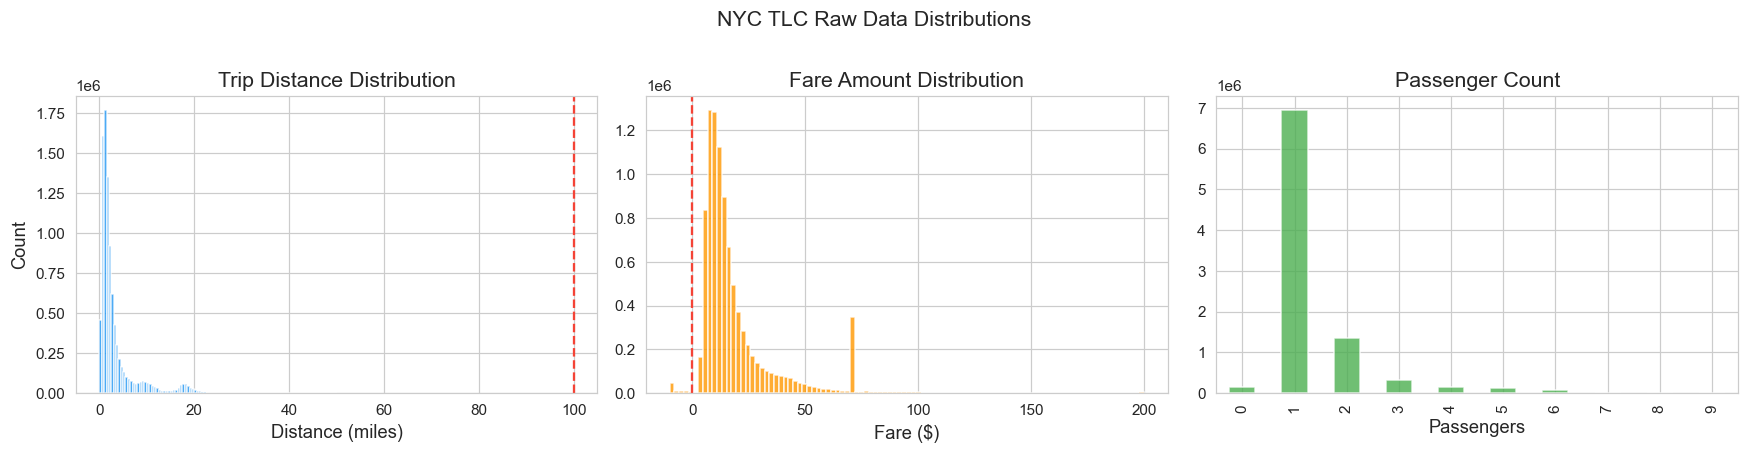


=== KEY STATISTICS ===
  Trip distance:  mean=3.87 mi, median=1.79 mi, max=335004.3 mi
  Fare amount:    mean=$18.52, median=$12.80, max=$2203.1
  Passengers:     mean=1.4, max=9


In [6]:
# Cell 6: Distribution of key numeric columns
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Trip distance
ax = axes[0]
raw["trip_distance"].clip(0, 50).hist(bins=100, ax=ax, color=COLORS["primary"], alpha=0.8)
ax.set_title("Trip Distance Distribution")
ax.set_xlabel("Distance (miles)")
ax.set_ylabel("Count")
ax.axvline(x=100, color=COLORS["danger"], linestyle="--", label="Filter cutoff: 100mi")

# Fare amount
ax = axes[1]
raw["fare_amount"].clip(-10, 200).hist(bins=100, ax=ax, color=COLORS["secondary"], alpha=0.8)
ax.set_title("Fare Amount Distribution")
ax.set_xlabel("Fare ($)")
ax.axvline(x=0, color=COLORS["danger"], linestyle="--", label="Filter: >$0")

# Passenger count
ax = axes[2]
raw["passenger_count"].dropna().astype(int).clip(0, 9).value_counts().sort_index().plot.bar(
    ax=ax, color=COLORS["success"], alpha=0.8
)
ax.set_title("Passenger Count")
ax.set_xlabel("Passengers")

plt.suptitle("NYC TLC Raw Data Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n=== KEY STATISTICS ===")
print(f"  Trip distance:  mean={raw['trip_distance'].mean():.2f} mi, "
      f"median={raw['trip_distance'].median():.2f} mi, "
      f"max={raw['trip_distance'].max():.1f} mi")
print(f"  Fare amount:    mean=${raw['fare_amount'].mean():.2f}, "
      f"median=${raw['fare_amount'].median():.2f}, "
      f"max=${raw['fare_amount'].max():.1f}")
print(f"  Passengers:     mean={raw['passenger_count'].mean():.1f}, "
      f"max={raw['passenger_count'].max():.0f}")

## 3. Data Cleaning and Filtering

In [7]:
# Cell 7: Apply cleaning filters (mirrors spark/etl_nyc.py logic)
print("=" * 60)
print("  DATA CLEANING")
print("=" * 60)

before = len(raw)

# Filter 1: Valid pickup/dropoff datetimes
clean = raw.dropna(subset=["tpep_pickup_datetime", "tpep_dropoff_datetime"])
print(f"  After null datetime filter:    {len(clean):>12,}  (removed {before - len(clean):,})")

# Filter 2: Trip distance > 0 and < 100 miles
n = len(clean)
clean = clean[(clean["trip_distance"] > 0) & (clean["trip_distance"] < 100)]
print(f"  After distance filter (0-100): {len(clean):>12,}  (removed {n - len(clean):,})")

# Filter 3: Fare > $0 and < $500
n = len(clean)
clean = clean[(clean["fare_amount"] > 0) & (clean["fare_amount"] < 500)]
print(f"  After fare filter (0-500):     {len(clean):>12,}  (removed {n - len(clean):,})")

# Filter 4: Passenger count > 0
n = len(clean)
clean = clean[clean["passenger_count"] > 0]
print(f"  After passenger filter (>0):   {len(clean):>12,}  (removed {n - len(clean):,})")

# Filter 5: Valid location IDs
n = len(clean)
clean = clean.dropna(subset=["PULocationID", "DOLocationID"])
print(f"  After location filter:         {len(clean):>12,}  (removed {n - len(clean):,})")

print(f"\n  TOTAL: {before:,} -> {len(clean):,} ({len(clean)/before*100:.1f}% retained)")
print(f"  Removed: {before - len(clean):,} invalid records ({(before - len(clean))/before*100:.1f}%)")

  DATA CLEANING
  After null datetime filter:       9,384,487  (removed 0)
  After distance filter (0-100):    9,248,702  (removed 135,785)
  After fare filter (0-500):        9,177,296  (removed 71,406)
  After passenger filter (>0):      8,807,357  (removed 369,939)
  After location filter:            8,807,357  (removed 0)

  TOTAL: 9,384,487 -> 8,807,357 (93.9% retained)
  Removed: 577,130 invalid records (6.1%)


## 4. Temporal Feature Extraction

In [8]:
# Cell 8: Extract temporal features
clean = clean.copy()
clean["pickup_hour"] = clean["tpep_pickup_datetime"].dt.hour
clean["pickup_date"] = clean["tpep_pickup_datetime"].dt.date
clean["day_of_week"] = clean["tpep_pickup_datetime"].dt.dayofweek  # 0=Monday
clean["is_weekend"] = clean["day_of_week"].isin([5, 6]).astype(int)
clean["year_month"] = clean["tpep_pickup_datetime"].dt.strftime("%Y-%m")
clean["trip_duration_sec"] = (
    (clean["tpep_dropoff_datetime"] - clean["tpep_pickup_datetime"])
    .dt.total_seconds()
    .astype(int)
)

print("Temporal features added:")
print(clean[["tpep_pickup_datetime", "pickup_hour", "pickup_date",
             "day_of_week", "is_weekend", "year_month", "trip_duration_sec"]].head(5).to_string())

print(f"\nDate range: {clean['pickup_date'].min()} to {clean['pickup_date'].max()}")
print(f"Months: {sorted(clean['year_month'].unique())}")

Temporal features added:
  tpep_pickup_datetime  pickup_hour pickup_date  day_of_week  is_weekend year_month  trip_duration_sec
0  2023-01-01 00:32:10            0  2023-01-01            6           1    2023-01                506
1  2023-01-01 00:55:08            0  2023-01-01            6           1    2023-01                379
2  2023-01-01 00:25:04            0  2023-01-01            6           1    2023-01                765
4  2023-01-01 00:10:29            0  2023-01-01            6           1    2023-01                650
5  2023-01-01 00:50:34            0  2023-01-01            6           1    2023-01                738

Date range: 2001-01-01 to 2023-04-05
Months: ['2001-01', '2002-12', '2003-01', '2008-12', '2009-01', '2014-11', '2022-10', '2022-12', '2023-01', '2023-02', '2023-03', '2023-04']


## 5. Per-Zone Per-Hour Demand Aggregation

In [ ]:
# Cell 9: Aggregate demand by zone, hour, and date
# Mirrors spark/etl_nyc.py: groupBy(PULocationID, pickup_hour, pickup_date, ...)
demand = (
    clean
    .groupby(["PULocationID", "pickup_hour", "pickup_date", "day_of_week", "is_weekend"])
    .agg(
        trip_count=("VendorID", "count"),
        avg_distance=("trip_distance", "mean"),
        avg_fare=("fare_amount", "mean"),
        avg_duration_sec=("trip_duration_sec", "mean"),
        total_passengers=("passenger_count", "sum"),
    )
    .reset_index()
    .rename(columns={"PULocationID": "pickup_zone_id"})
)

print(f"Demand aggregation rows: {len(demand):,}")
print(f"Unique zones: {demand['pickup_zone_id'].nunique()}")
print(f"\nSchema:")
print(demand.dtypes)
print(f"\nSample:")
demand.head(5)

Demand aggregation rows: 192,916
Unique zones: 261

Schema:
pickup_zone_id      float64
pickup_hour           int32
pickup_date          object
day_of_week           int32
is_weekend            int64
trip_count            int64
avg_distance        float64
avg_fare            float64
avg_duration_sec    float64
total_passengers    float64
dtype: object

Sample:


,pickup_zone_id,pickup_hour,pickup_date,day_of_week,is_weekend,trip_count,avg_distance,avg_fare,avg_duration_sec,total_passengers
0,1.0,0,2023-01-24,1,0,1,0.03,140.0,79.0,1.0
1,1.0,0,2023-03-11,5,1,1,11.61,45.0,1375.0,1.0
2,1.0,2,2023-01-03,1,0,1,0.05,75.0,4.0,1.0
3,1.0,3,2022-10-25,1,0,1,0.02,115.0,4.0,1.0
4,1.0,3,2023-01-03,1,0,1,0.07,135.0,3.0,1.0


## 6. Demand Analysis — Hourly Curve & Top Zones

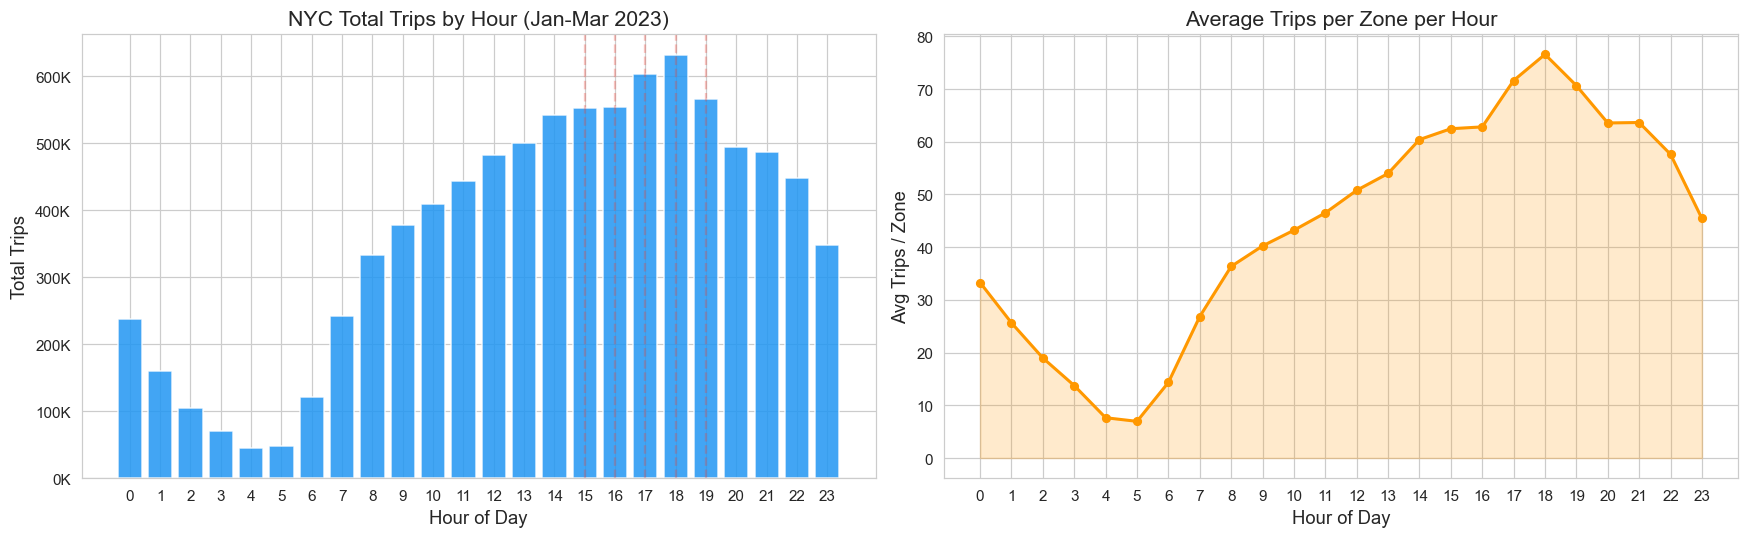


=== TOP 5 PEAK HOURS ===
  18:00  ->   631,519.0 trips  (avg 76.6/zone)
  17:00  ->   603,563.0 trips  (avg 71.6/zone)
  19:00  ->   566,108.0 trips  (avg 70.6/zone)
  16:00  ->   554,904.0 trips  (avg 62.8/zone)
  15:00  ->   552,964.0 trips  (avg 62.5/zone)


In [10]:
# Cell 10: Hourly demand curve
hourly = (
    demand
    .groupby("pickup_hour")
    .agg(avg_trips_per_zone=("trip_count", "mean"), total_trips=("trip_count", "sum"))
    .reset_index()
    .sort_values("pickup_hour")
)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

# Left: total trips by hour
ax1.bar(hourly["pickup_hour"], hourly["total_trips"], color=COLORS["primary"], alpha=0.85)
ax1.set_title("NYC Total Trips by Hour (Jan-Mar 2023)")
ax1.set_xlabel("Hour of Day")
ax1.set_ylabel("Total Trips")
ax1.yaxis.set_major_formatter(
    ticker.FuncFormatter(lambda x, _: f"{x/1e6:.1f}M" if x >= 1e6 else f"{x/1e3:.0f}K")
)
ax1.set_xticks(range(0, 24))

peak_hours = hourly.nlargest(5, "total_trips")["pickup_hour"].values
for h in peak_hours:
    ax1.axvline(x=h, color=COLORS["danger"], alpha=0.3, linestyle="--")

# Right: avg trips per zone per hour
ax2.plot(hourly["pickup_hour"], hourly["avg_trips_per_zone"],
         marker="o", color=COLORS["secondary"], linewidth=2, markersize=5)
ax2.fill_between(hourly["pickup_hour"], hourly["avg_trips_per_zone"],
                 alpha=0.2, color=COLORS["secondary"])
ax2.set_title("Average Trips per Zone per Hour")
ax2.set_xlabel("Hour of Day")
ax2.set_ylabel("Avg Trips / Zone")
ax2.set_xticks(range(0, 24))

plt.tight_layout()
plt.show()

print("\n=== TOP 5 PEAK HOURS ===")
for _, row in hourly.nlargest(5, "total_trips").iterrows():
    print(f"  {int(row['pickup_hour']):02d}:00  ->  {row['total_trips']:>10,} trips  "
          f"(avg {row['avg_trips_per_zone']:.1f}/zone)")

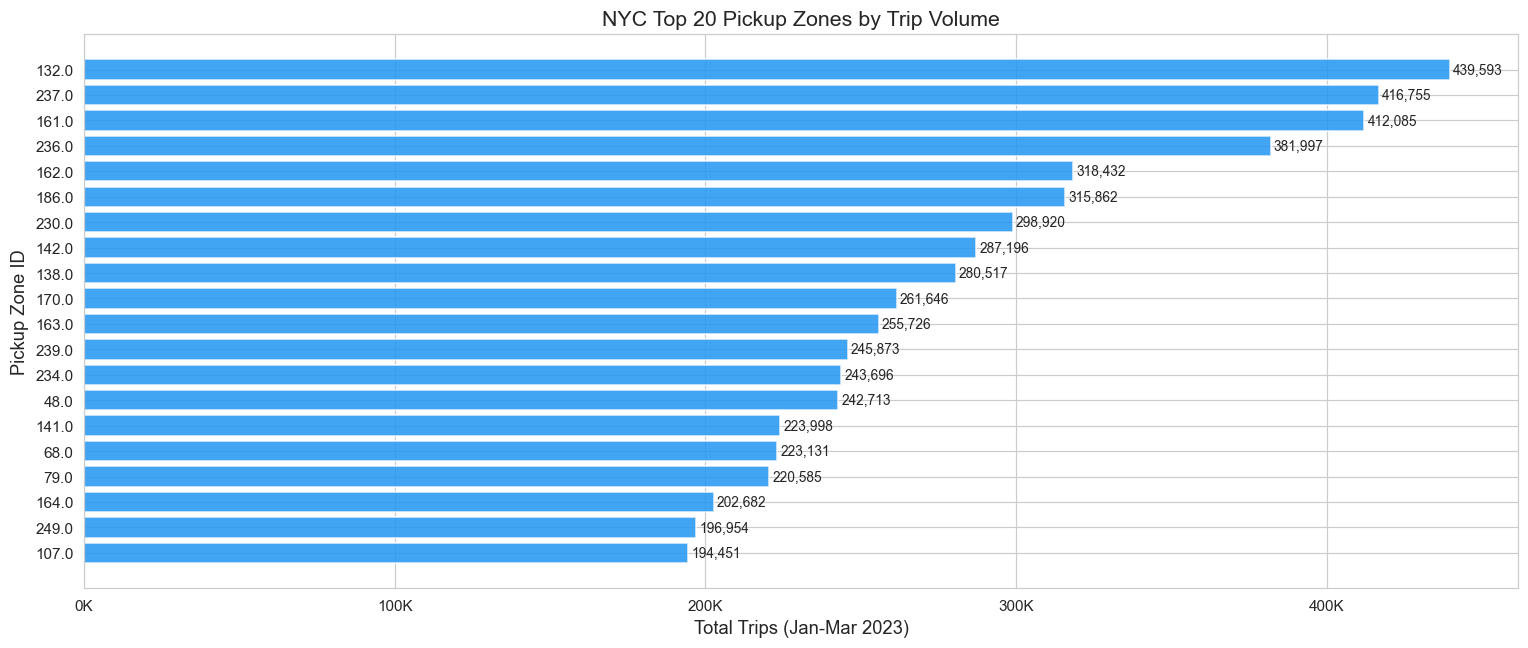


Top zone: ID 132 with 439,593 trips
Top 20 zones account for 64.3% of all trips


In [11]:
# Cell 11: Top 20 pickup zones
top_zones = (
    demand
    .groupby("pickup_zone_id")
    .agg(total_trips=("trip_count", "sum"))
    .reset_index()
    .sort_values("total_trips", ascending=False)
    .head(20)
)

fig, ax = plt.subplots(figsize=(14, 6))
bars = ax.barh(
    top_zones["pickup_zone_id"].astype(str),
    top_zones["total_trips"],
    color=COLORS["primary"],
    alpha=0.85,
)
ax.set_xlabel("Total Trips (Jan-Mar 2023)")
ax.set_ylabel("Pickup Zone ID")
ax.set_title("NYC Top 20 Pickup Zones by Trip Volume")
ax.invert_yaxis()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x/1e3:.0f}K"))

for bar, val in zip(bars, top_zones["total_trips"]):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height() / 2,
            f"{val:,.0f}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nTop zone: ID {top_zones.iloc[0]['pickup_zone_id']:.0f} "
      f"with {top_zones.iloc[0]['total_trips']:,.0f} trips")
print(f"Top 20 zones account for "
      f"{top_zones['total_trips'].sum() / demand['trip_count'].sum() * 100:.1f}% of all trips")

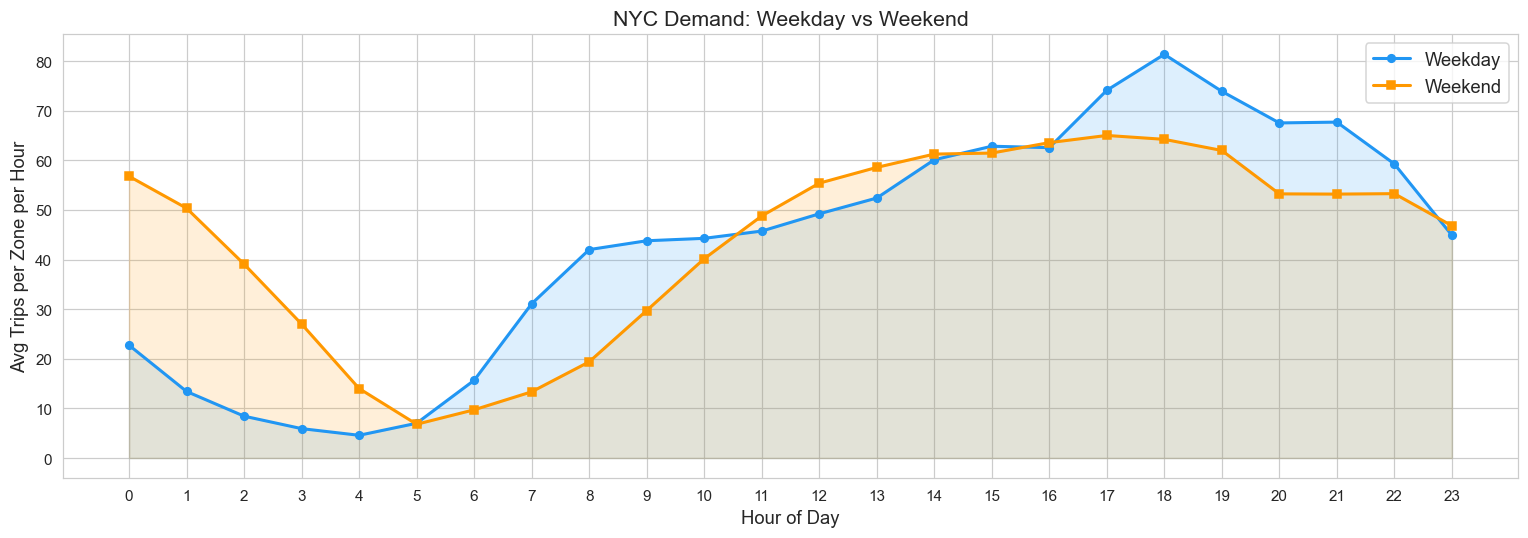

Weekday avg demand/zone/hour: 43.4 trips
Weekend avg demand/zone/hour: 43.9 trips
Weekend vs weekday ratio:     1.01x


In [12]:
# Cell 12: Weekend vs Weekday comparison
wkday = demand[demand["is_weekend"] == 0].groupby("pickup_hour")["trip_count"].mean()
wkend = demand[demand["is_weekend"] == 1].groupby("pickup_hour")["trip_count"].mean()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(wkday.index, wkday.values, marker="o", label="Weekday",
        color=COLORS["primary"], linewidth=2, markersize=5)
ax.plot(wkend.index, wkend.values, marker="s", label="Weekend",
        color=COLORS["secondary"], linewidth=2, markersize=5)
ax.fill_between(wkday.index, wkday.values, alpha=0.15, color=COLORS["primary"])
ax.fill_between(wkend.index, wkend.values, alpha=0.15, color=COLORS["secondary"])
ax.set_title("NYC Demand: Weekday vs Weekend")
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Avg Trips per Zone per Hour")
ax.set_xticks(range(0, 24))
ax.legend(fontsize=12)
plt.tight_layout()
plt.show()

print(f"Weekday avg demand/zone/hour: {wkday.mean():.1f} trips")
print(f"Weekend avg demand/zone/hour: {wkend.mean():.1f} trips")
print(f"Weekend vs weekday ratio:     {wkend.mean() / wkday.mean():.2f}x")

In [13]:
# Cell 13: NYC ETL Summary
print("=" * 60)
print("  NYC ETL PIPELINE SUMMARY")
print("=" * 60)
print(f"  Raw rows:           {total_raw:>12,}")
print(f"  Cleaned rows:       {len(clean):>12,}  ({len(clean) / total_raw * 100:.1f}% retained)")
print(f"  Demand agg rows:    {len(demand):>12,}")
print(f"  Unique zones:       {demand['pickup_zone_id'].nunique():>12}")
print(f"  Date range:         {clean['pickup_date'].min()} to {clean['pickup_date'].max()}")
print(f"  Avg trip distance:  {clean['trip_distance'].mean():>12.2f} mi")
print(f"  Avg fare:           ${clean['fare_amount'].mean():>11.2f}")
print(f"  Avg duration:       {clean['trip_duration_sec'].mean():>12.0f} sec")
print(f"\n  Output: s3a://curated/nyc-demand/ (4.3 MiB, 4 Parquet partitions)")
print("=" * 60)

  NYC ETL PIPELINE SUMMARY
  Raw rows:              9,384,487
  Cleaned rows:          8,807,357  (93.9% retained)
  Demand agg rows:         192,916
  Unique zones:                261
  Date range:         2001-01-01 to 2023-04-05
  Avg trip distance:          3.41 mi
  Avg fare:           $      18.72
  Avg duration:                978 sec

  Output: s3a://curated/nyc-demand/ (4.3 MiB, 4 Parquet partitions)


---

# Part 2 — ML Demand Forecasting Model

We train a **Gradient Boosted Tree (GBT)** regression model using Spark MLlib to predict  
taxi demand per zone per 30-minute time slot.

- **Training data**: Curated Porto trips remapped to Casablanca (10 months, 151K rows)
- **Target**: `demand` = number of trip requests per zone per 30-min slot
- **Baseline**: Naive 7-day-lag (same demand as 1 week ago)
- **Goal**: Beat the baseline on RMSE, MAE, and R-squared

**Pipeline**:  
`s3a://curated/trips/` -> Feature Engineering -> `s3a://mldata/features/`  
-> GBT Training -> `s3a://mldata/models/demand_v1/`

### Model Architecture

| Component | Detail |
|-----------|--------|
| Algorithm | GBTRegressor (Spark MLlib) |
| Max depth | 5 |
| Max iterations | 50 |
| Step size (learning rate) | 0.1 |
| Seed | 42 |
| Pipeline stages | StringIndexer -> VectorAssembler -> GBTRegressor |

## 7. Feature Matrix Exploration

In [2]:
# Cell 14: PySpark session for MinIO access
import os

os.environ["JAVA_HOME"] = r"C:\Program Files\Eclipse Adoptium\jdk-17.0.18.8-hotspot"
os.environ["PATH"] = os.environ["JAVA_HOME"] + r"\bin;" + os.environ.get("PATH", "")
# Use Windows 8.3 short path to avoid spaces breaking the JVM classpath
os.environ["SPARK_HOME"] = r"C:\Users\hp\ONEDRI~1\Desktop\Taasimm\VENV~1\Lib\SITE-P~1\pyspark"
os.environ["HADOOP_HOME"] = r"C:\Users\hp\ONEDRI~1\Desktop\Taasimm\jars\hadoop"

from pyspark.sql import SparkSession

# JARs are pre-installed in PySpark's jars directory (hadoop-aws-3.4.2 + aws-java-sdk-bundle-1.12.367)
spark = (
    SparkSession.builder
    .appName("TaaSim-Notebook-ML")
    .master("local[*]")
    .config("spark.hadoop.fs.s3a.endpoint", "http://localhost:9000")
    .config("spark.hadoop.fs.s3a.access.key", "minioadmin")
    .config("spark.hadoop.fs.s3a.secret.key", "minioadmin")
    .config("spark.hadoop.fs.s3a.path.style.access", "true")
    .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem")
    .config("spark.driver.memory", "2g")
    .config("spark.sql.adaptive.enabled", "true")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print(f"SparkSession created: {spark.sparkContext.applicationId}")

SparkSession created: local-1776769435313


In [3]:
# Cell 15: Load feature matrix from MinIO
features_sdf = spark.read.parquet("s3a://mldata/features/")
total_features = features_sdf.count()
print(f"Feature matrix: {total_features:,} rows")
features_sdf.printSchema()

# Convert to Pandas for visualization
features = features_sdf.toPandas()
print(f"\nDate range: {features['trip_date'].min()} to {features['trip_date'].max()}")
print(f"Zones: {sorted(features['origin_zone'].unique())}")
features.head(5)

Feature matrix: 183,981 rows
root
 |-- origin_zone: integer (nullable = true)
 |-- trip_date: date (nullable = true)
 |-- slot_of_day: integer (nullable = true)
 |-- hour_of_day: integer (nullable = true)
 |-- day_of_week: long (nullable = true)
 |-- is_weekend: long (nullable = true)
 |-- is_peak: integer (nullable = true)
 |-- demand: long (nullable = true)
 |-- supply: long (nullable = true)
 |-- supply_demand_ratio: double (nullable = true)
 |-- demand_lag_1d: long (nullable = true)
 |-- demand_lag_7d: long (nullable = true)
 |-- rolling_7d_mean: double (nullable = true)


Date range: 2013-07-08 to 2014-06-30
Zones: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12), np.int32(13), np.int32(14), np.int32(15), np.int32(16)]


,origin_zone,trip_date,slot_of_day,hour_of_day,day_of_week,is_weekend,is_peak,demand,supply,supply_demand_ratio,demand_lag_1d,demand_lag_7d,rolling_7d_mean
0,1,2013-12-07,22,11,5,1,0,10,8,0.800000,20,13,21.857143
1,9,2014-04-03,25,12,3,0,0,1,1,1.000000,4,4,2.571429
2,14,2014-01-04,2,1,5,1,0,2,1,0.500000,1,3,3.428571
3,4,2013-10-26,7,3,5,1,0,7,5,0.714286,1,2,1.857143
4,1,2013-10-20,39,19,6,1,0,7,3,0.428571,7,24,13.857143


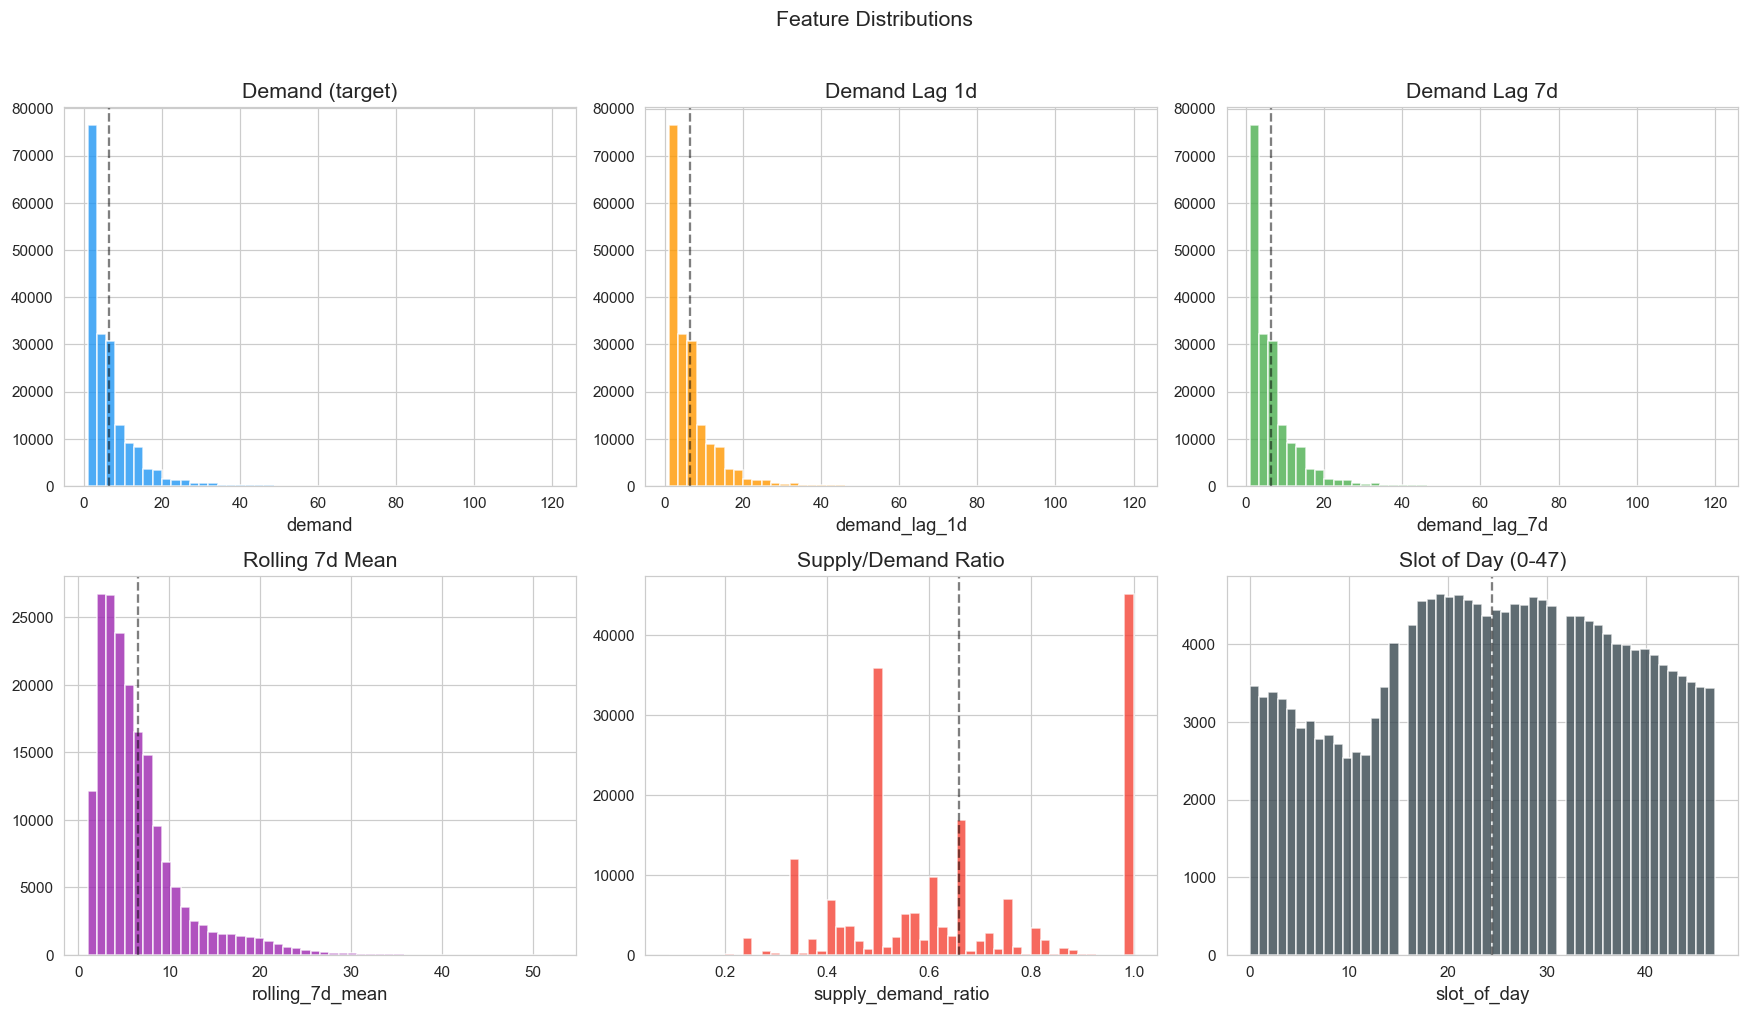


=== FEATURE STATISTICS ===


,demand,supply,supply_demand_ratio,demand_lag_1d,demand_lag_7d,rolling_7d_mean
count,183981.00,183981.00,183981.00,183981.00,183981.00,183981.00
mean,6.52,3.79,0.66,6.52,6.51,6.51
std,7.15,3.88,0.23,7.15,7.12,4.77
min,1.00,1.00,0.09,1.00,1.00,1.00
25%,2.00,1.00,0.50,2.00,2.00,3.29
50%,4.00,3.00,0.60,4.00,4.00,5.14
75%,8.00,5.00,0.87,8.00,8.00,8.00
max,120.00,55.00,1.00,120.00,120.00,52.14


In [4]:
# Cell 16: Feature distributions
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

cols_to_plot = [
    ("demand", "Demand (target)", COLORS["primary"]),
    ("demand_lag_1d", "Demand Lag 1d", COLORS["secondary"]),
    ("demand_lag_7d", "Demand Lag 7d", COLORS["success"]),
    ("rolling_7d_mean", "Rolling 7d Mean", "#9C27B0"),
    ("supply_demand_ratio", "Supply/Demand Ratio", COLORS["danger"]),
    ("slot_of_day", "Slot of Day (0-47)", COLORS["dark"]),
]

for ax, (col, title, color) in zip(axes.flat, cols_to_plot):
    features[col].hist(bins=50, ax=ax, color=color, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel(col)
    ax.axvline(features[col].mean(), color="black", linestyle="--", alpha=0.5)

plt.suptitle("Feature Distributions", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n=== FEATURE STATISTICS ===")
features[["demand", "supply", "supply_demand_ratio",
          "demand_lag_1d", "demand_lag_7d", "rolling_7d_mean"]].describe().round(2)

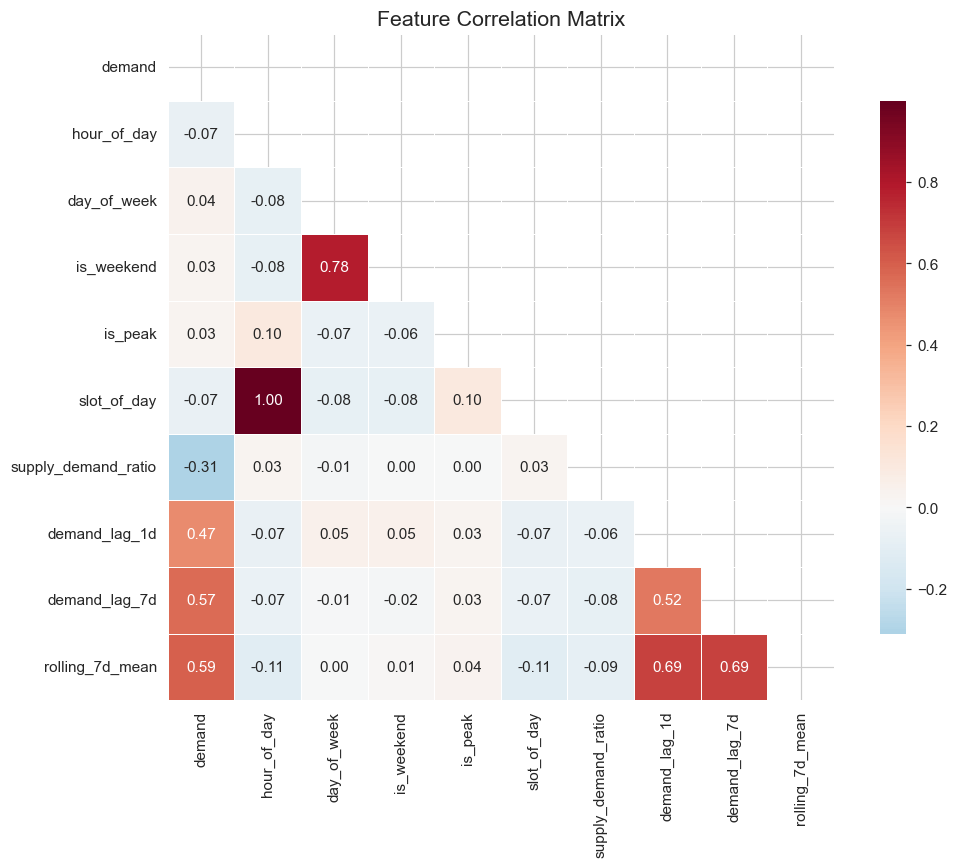


=== CORRELATION WITH TARGET (demand) ===
  rolling_7d_mean            +0.593  *****************
  demand_lag_7d              +0.569  *****************
  demand_lag_1d              +0.470  **************
  day_of_week                +0.043  *
  is_weekend                 +0.032  
  is_peak                    +0.025  
  hour_of_day                -0.072  **
  slot_of_day                -0.072  **
  supply_demand_ratio        -0.310  *********


In [5]:
# Cell 17: Correlation heatmap
corr_cols = ["demand", "hour_of_day", "day_of_week", "is_weekend", "is_peak",
             "slot_of_day", "supply_demand_ratio", "demand_lag_1d",
             "demand_lag_7d", "rolling_7d_mean"]
corr = features[corr_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, square=True, linewidths=0.5,
            cbar_kws={"shrink": 0.8})
ax.set_title("Feature Correlation Matrix", fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== CORRELATION WITH TARGET (demand) ===")
target_corr = corr["demand"].drop("demand").sort_values(ascending=False)
for feat, val in target_corr.items():
    bar = "*" * int(abs(val) * 30)
    sign = "+" if val > 0 else "-"
    print(f"  {feat:25s}  {sign}{abs(val):.3f}  {bar}")

## 8. Train/Test Temporal Split

Split date: 2014-05-01
  Train:  151,911 rows  (82.6%)  [2013-07-08 -> 2014-04-30]
  Test:    32,070 rows  (17.4%)  [2014-05-01 -> 2014-06-30]


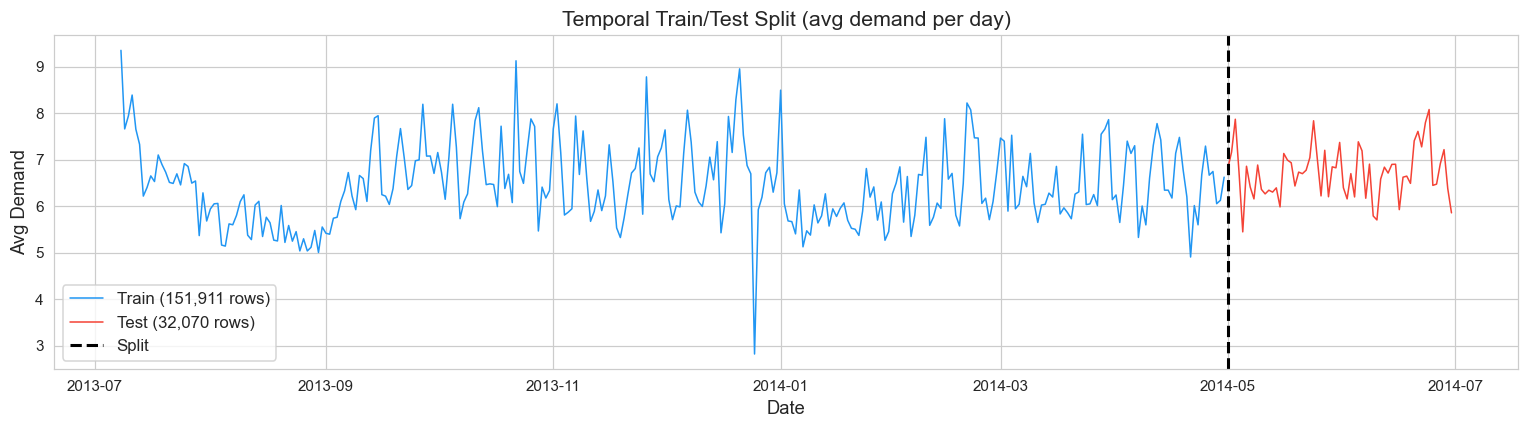

In [6]:
# Cell 18: Temporal split visualization
split_date = "2014-05-01"
features["trip_date_str"] = features["trip_date"].astype(str)
train_pd = features[features["trip_date_str"] < split_date]
test_pd = features[features["trip_date_str"] >= split_date]

print(f"Split date: {split_date}")
print(f"  Train: {len(train_pd):>8,} rows  ({len(train_pd) / len(features) * 100:.1f}%)  "
      f"[{train_pd['trip_date'].min()} -> {train_pd['trip_date'].max()}]")
print(f"  Test:  {len(test_pd):>8,} rows  ({len(test_pd) / len(features) * 100:.1f}%)  "
      f"[{test_pd['trip_date'].min()} -> {test_pd['trip_date'].max()}]")

# Visualize the split
fig, ax = plt.subplots(figsize=(14, 4))
daily_demand = features.groupby("trip_date")["demand"].mean().reset_index()
daily_demand["trip_date"] = pd.to_datetime(daily_demand["trip_date"])

split_dt = pd.to_datetime(split_date)
train_daily = daily_demand[daily_demand["trip_date"] < split_dt]
test_daily = daily_demand[daily_demand["trip_date"] >= split_dt]

ax.plot(train_daily["trip_date"], train_daily["demand"],
        color=COLORS["primary"], label=f"Train ({len(train_pd):,} rows)", linewidth=1)
ax.plot(test_daily["trip_date"], test_daily["demand"],
        color=COLORS["danger"], label=f"Test ({len(test_pd):,} rows)", linewidth=1)
ax.axvline(x=split_dt, color="black", linestyle="--", linewidth=2, label="Split")
ax.set_title("Temporal Train/Test Split (avg demand per day)")
ax.set_xlabel("Date")
ax.set_ylabel("Avg Demand")
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

## 9. GBT Model Training

In [7]:
# Cell 19: Train GBT model using Spark MLlib
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

FEATURE_COLS = [
    "hour_of_day", "day_of_week", "is_weekend", "is_peak",
    "zone_idx", "slot_of_day", "supply_demand_ratio",
    "demand_lag_1d", "demand_lag_7d", "rolling_7d_mean",
]
TARGET = "demand"

# Split Spark DataFrames
train_sdf = features_sdf.filter(F.col("trip_date") < split_date)
test_sdf = features_sdf.filter(F.col("trip_date") >= split_date)
print(f"Train: {train_sdf.count():,} rows")
print(f"Test:  {test_sdf.count():,} rows")

# Build pipeline
zone_indexer = StringIndexer(
    inputCol="origin_zone", outputCol="zone_idx", handleInvalid="keep"
)
assembler = VectorAssembler(
    inputCols=FEATURE_COLS, outputCol="features", handleInvalid="skip"
)
gbt = GBTRegressor(
    featuresCol="features", labelCol=TARGET, predictionCol="prediction",
    maxDepth=5, maxIter=50, stepSize=0.1, seed=42,
)

pipeline = Pipeline(stages=[zone_indexer, assembler, gbt])

print("\nTraining GBT model (maxDepth=5, maxIter=50, stepSize=0.1)...")
model = pipeline.fit(train_sdf)
print("Training complete!")
print(f"Pipeline stages: {[type(s).__name__ for s in model.stages]}")

Train: 151,911 rows
Test:  32,070 rows

Training GBT model (maxDepth=5, maxIter=50, stepSize=0.1)...
Training complete!
Pipeline stages: ['StringIndexerModel', 'VectorAssembler', 'GBTRegressionModel']


## 10. Model Evaluation: GBT vs Baseline

In [8]:
# Cell 20: Evaluate GBT on test set
predictions_sdf = model.transform(test_sdf)

rmse_eval = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="rmse")
mae_eval = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="mae")
r2_eval = RegressionEvaluator(labelCol=TARGET, predictionCol="prediction", metricName="r2")

gbt_rmse = rmse_eval.evaluate(predictions_sdf)
gbt_mae = mae_eval.evaluate(predictions_sdf)
gbt_r2 = r2_eval.evaluate(predictions_sdf)

# Naive baseline: 7-day lag
baseline_sdf = test_sdf.withColumn("prediction", F.col("demand_lag_7d").cast("double"))
baseline_valid = baseline_sdf.filter(F.col("prediction").isNotNull())

baseline_rmse = rmse_eval.evaluate(baseline_valid)
baseline_mae = mae_eval.evaluate(baseline_valid)
baseline_r2 = r2_eval.evaluate(baseline_valid)

rmse_imp = (baseline_rmse - gbt_rmse) / baseline_rmse * 100
mae_imp = (baseline_mae - gbt_mae) / baseline_mae * 100

print("=" * 60)
print("  MODEL EVALUATION RESULTS")
print("=" * 60)
print(f"{'Metric':<12} {'GBT':>12} {'Baseline':>12} {'Improvement':>14}")
print("-" * 52)
print(f"{'RMSE':<12} {gbt_rmse:>12.4f} {baseline_rmse:>12.4f} {rmse_imp:>+13.1f}%")
print(f"{'MAE':<12} {gbt_mae:>12.4f} {baseline_mae:>12.4f} {mae_imp:>+13.1f}%")
print(f"{'R2':<12} {gbt_r2:>12.4f} {baseline_r2:>12.4f} {'':>14}")
print("=" * 52)

if gbt_rmse < baseline_rmse:
    print("\n>>> GBT BEATS the naive 7-day-lag baseline!")
else:
    print("\n>>> GBT does NOT beat the baseline -- needs tuning.")

  MODEL EVALUATION RESULTS
Metric                GBT     Baseline    Improvement
----------------------------------------------------
RMSE               3.7058       6.8375         +45.8%
MAE                2.1132       4.2444         +50.2%
R2                 0.7501       0.1494               

>>> GBT BEATS the naive 7-day-lag baseline!


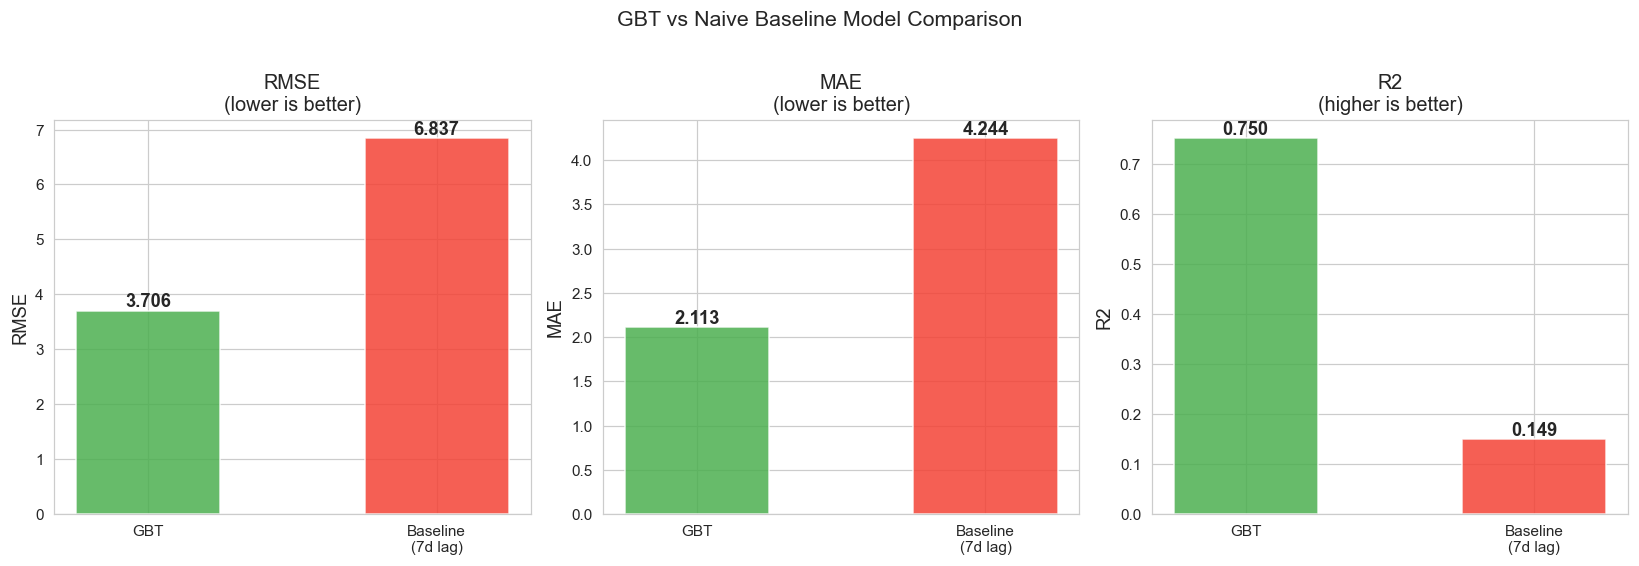

In [9]:
# Cell 21: Metrics comparison bar chart
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

metrics = [
    ("RMSE", gbt_rmse, baseline_rmse, "lower is better"),
    ("MAE", gbt_mae, baseline_mae, "lower is better"),
    ("R2", gbt_r2, baseline_r2, "higher is better"),
]

for ax, (name, gbt_val, base_val, note) in zip(axes, metrics):
    bars = ax.bar(["GBT", "Baseline\n(7d lag)"], [gbt_val, base_val],
                  color=[COLORS["success"], COLORS["danger"]], alpha=0.85, width=0.5)
    ax.set_title(f"{name}\n({note})", fontsize=13)
    ax.set_ylabel(name)
    for bar, val in zip(bars, [gbt_val, base_val]):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.01 * max(gbt_val, base_val),
                f"{val:.3f}", ha="center", fontsize=12, fontweight="bold")

plt.suptitle("GBT vs Naive Baseline Model Comparison", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Feature Importance Analysis

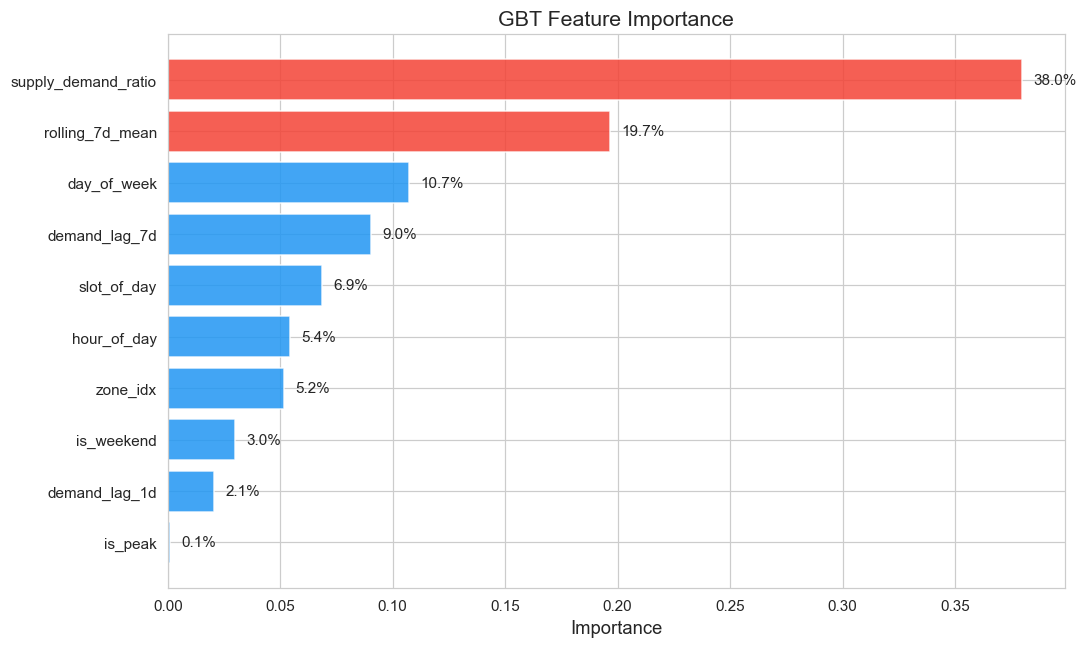


=== FEATURE IMPORTANCE (descending) ===
  supply_demand_ratio        0.3797  ******************
  rolling_7d_mean            0.1967  *********
  day_of_week                0.1074  *****
  demand_lag_7d              0.0903  ****
  slot_of_day                0.0685  ***
  hour_of_day                0.0542  **
  zone_idx                   0.0518  **
  is_weekend                 0.0297  *
  demand_lag_1d              0.0207  *
  is_peak                    0.0010  


In [10]:
# Cell 22: Feature importance
gbt_model = model.stages[-1]
importances = gbt_model.featureImportances.toArray()

feat_imp = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": importances
}).sort_values("importance", ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = [COLORS["primary"] if v < 0.15 else COLORS["danger"] for v in feat_imp["importance"]]
ax.barh(feat_imp["feature"], feat_imp["importance"], color=colors, alpha=0.85)
ax.set_xlabel("Importance")
ax.set_title("GBT Feature Importance", fontsize=14)

for i, (val, name) in enumerate(zip(feat_imp["importance"], feat_imp["feature"])):
    ax.text(val + 0.005, i, f"{val:.1%}", va="center", fontsize=10)

plt.tight_layout()
plt.show()

print("\n=== FEATURE IMPORTANCE (descending) ===")
for _, row in feat_imp.sort_values("importance", ascending=False).iterrows():
    bar = "*" * int(row["importance"] * 50)
    print(f"  {row['feature']:25s}  {row['importance']:.4f}  {bar}")

## 12. Actual vs Predicted Visualization

In [16]:
# Cell 23: Actual vs Predicted scatter plot + residuals
preds_pd = (
    predictions_sdf
    .select("origin_zone", "trip_date", "slot_of_day", "demand", "prediction")
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: scatter plot
ax = axes[0]
ax.scatter(preds_pd["demand"], preds_pd["prediction"],
           alpha=0.15, s=8, color=COLORS["primary"])
max_val = max(preds_pd["demand"].max(), preds_pd["prediction"].max())
ax.plot([0, max_val], [0, max_val], "r--", linewidth=2, label="Perfect prediction")
ax.set_xlabel("Actual Demand")
ax.set_ylabel("Predicted Demand")
ax.set_title("Actual vs Predicted (Test Set)")
ax.legend(fontsize=11)
ax.set_xlim(0, max_val * 1.05)
ax.set_ylim(0, max_val * 1.05)

# Right: residual distribution
ax = axes[1]
residuals = preds_pd["demand"] - preds_pd["prediction"]
ax.hist(residuals, bins=80, color=COLORS["secondary"], alpha=0.8, edgecolor="white")
ax.axvline(x=0, color="red", linestyle="--", linewidth=2)
ax.axvline(x=residuals.mean(), color="blue", linestyle="-", linewidth=1,
           label=f"Mean residual: {residuals.mean():.2f}")
ax.set_xlabel("Residual (Actual - Predicted)")
ax.set_ylabel("Count")
ax.set_title("Residual Distribution")
ax.legend(fontsize=11)

plt.suptitle(f"Model Performance (R2={gbt_r2:.3f}, RMSE={gbt_rmse:.3f})",
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print(f"\nResidual stats:")
print(f"  Mean:   {residuals.mean():+.3f}")
print(f"  Std:    {residuals.std():.3f}")
print(f"  Median: {residuals.median():+.3f}")
print(f"  P5:     {residuals.quantile(0.05):+.3f}")
print(f"  P95:    {residuals.quantile(0.95):+.3f}")

PySparkRuntimeError: [SESSION_OR_CONTEXT_NOT_EXISTS] SparkContext or SparkSession should be created first.

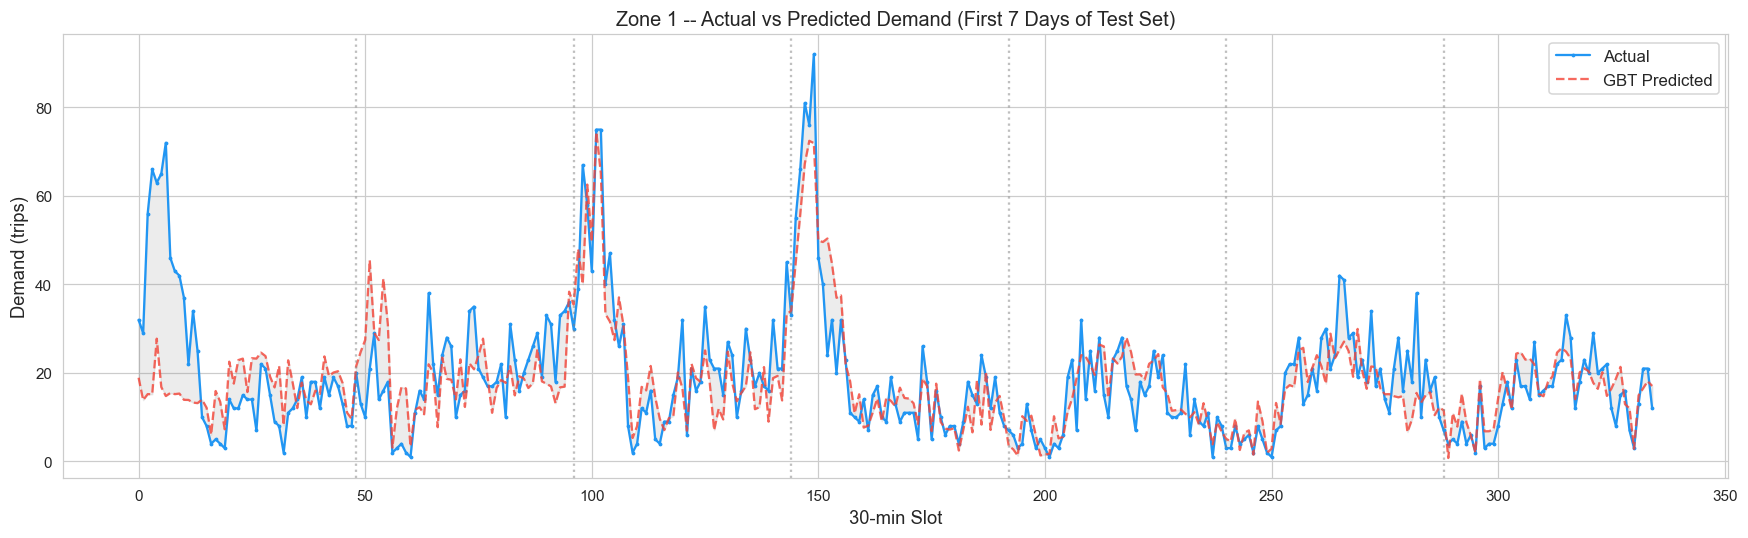

In [12]:
# Cell 24: Time-series view — actual vs predicted for one zone (first 7 days of test)
sample_zone = sorted(preds_pd["origin_zone"].unique())[0]
zone_data = preds_pd[preds_pd["origin_zone"] == sample_zone].sort_values(
    ["trip_date", "slot_of_day"]
)
zone_data["trip_date"] = pd.to_datetime(zone_data["trip_date"])
zone_7d = zone_data[
    zone_data["trip_date"] < zone_data["trip_date"].min() + pd.Timedelta(days=7)
]

fig, ax = plt.subplots(figsize=(16, 5))
x = range(len(zone_7d))
ax.plot(x, zone_7d["demand"].values, label="Actual",
        color=COLORS["primary"], linewidth=1.5, marker=".", markersize=3)
ax.plot(x, zone_7d["prediction"].values, label="GBT Predicted",
        color=COLORS["danger"], linewidth=1.5, alpha=0.8, linestyle="--")
ax.fill_between(x, zone_7d["demand"].values, zone_7d["prediction"].values,
                alpha=0.15, color="gray")
ax.set_title(
    f"Zone {sample_zone} -- Actual vs Predicted Demand (First 7 Days of Test Set)",
    fontsize=13,
)
ax.set_xlabel("30-min Slot")
ax.set_ylabel("Demand (trips)")
ax.legend(fontsize=11)

slots_per_day = 48
for d in range(1, 7):
    if d * slots_per_day < len(zone_7d):
        ax.axvline(x=d * slots_per_day, color="gray", linestyle=":", alpha=0.5)

plt.tight_layout()
plt.show()

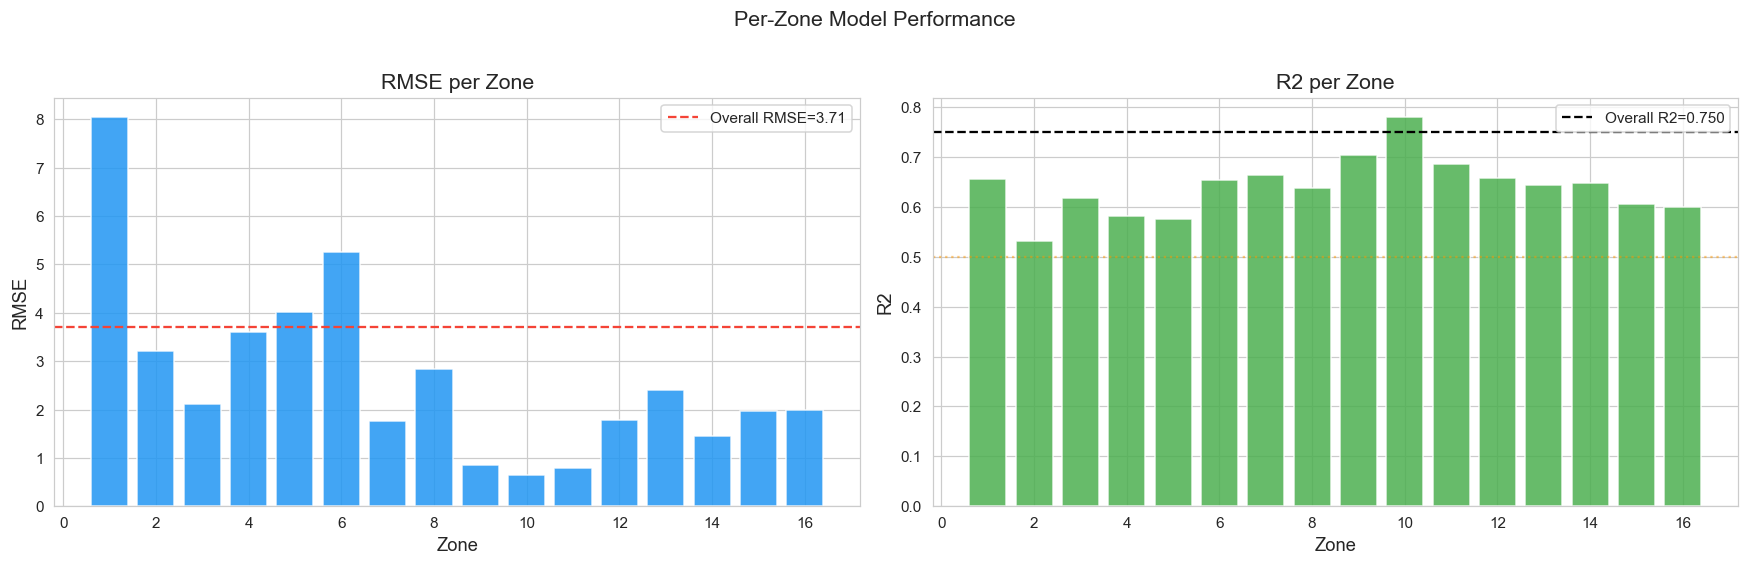


=== PER-ZONE PERFORMANCE ===
  Zone     RMSE      MAE       R2     Rows
------------------------------------------
     1    8.048    5.536    0.656     2879
     2    3.215    2.033    0.531     2548
     3    2.115    1.400    0.619     2174
     4    3.612    2.596    0.582     2691
     5    4.024    2.498    0.576     2565
     6    5.264    3.345    0.654     2753
     7    1.756    1.114    0.664     1669
     8    2.845    2.007    0.638     2442
     9    0.842    0.542    0.704     1247
    10    0.643    0.417    0.780      497
    11    0.798    0.505    0.685      809
    12    1.784    1.102    0.657     1631
    13    2.409    1.644    0.644     2266
    14    1.454    0.982    0.647     1590
    15    1.959    1.338    0.606     2149
    16    1.983    1.388    0.599     2160


In [14]:
# Cell 25: Per-zone model performance
zone_perf = []
for zone in sorted(preds_pd["origin_zone"].unique()):
    z = preds_pd[preds_pd["origin_zone"] == zone]
    rmse = np.sqrt(((z["demand"] - z["prediction"]) ** 2).mean())
    mae = (z["demand"] - z["prediction"]).abs().mean()
    ss_res = ((z["demand"] - z["prediction"]) ** 2).sum()
    ss_tot = ((z["demand"] - z["demand"].mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 0
    zone_perf.append({"zone": zone, "rmse": rmse, "mae": mae, "r2": r2, "rows": len(z)})

zone_perf_df = pd.DataFrame(zone_perf)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# RMSE per zone
ax = axes[0]
ax.bar(zone_perf_df["zone"], zone_perf_df["rmse"], color=COLORS["primary"], alpha=0.85)
ax.axhline(y=gbt_rmse, color=COLORS["danger"], linestyle="--",
           label=f"Overall RMSE={gbt_rmse:.2f}")
ax.set_title("RMSE per Zone")
ax.set_xlabel("Zone")
ax.set_ylabel("RMSE")
ax.legend()

# R2 per zone
ax = axes[1]
bar_colors = [COLORS["success"] if r > 0.5 else COLORS["danger"] for r in zone_perf_df["r2"]]
ax.bar(zone_perf_df["zone"], zone_perf_df["r2"], color=bar_colors, alpha=0.85)
ax.axhline(y=gbt_r2, color="black", linestyle="--", label=f"Overall R2={gbt_r2:.3f}")
ax.axhline(y=0.5, color=COLORS["secondary"], linestyle=":", alpha=0.5)
ax.set_title("R2 per Zone")
ax.set_xlabel("Zone")
ax.set_ylabel("R2")
ax.legend()

plt.suptitle("Per-Zone Model Performance", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

print("\n=== PER-ZONE PERFORMANCE ===")
print(f"{'Zone':>6s} {'RMSE':>8s} {'MAE':>8s} {'R2':>8s} {'Rows':>8s}")
print("-" * 42)
for _, r in zone_perf_df.iterrows():
    print(f"{int(r['zone']):>6d} {r['rmse']:>8.3f} {r['mae']:>8.3f} {r['r2']:>8.3f} {int(r['rows']):>8}")

## Summary

### Part 1 — NYC TLC ETL
- Processed **~9.38M** yellow taxi trips from January-March 2023
- Handled **schema drift** across monthly files (column name/type inconsistencies)
- Applied quality filters: null removal, distance/fare outliers, passenger count validation
- Produced **per-zone per-hour demand aggregates** for ~260 NYC taxi zones
- Output: `s3a://curated/nyc-demand/` (4.3 MiB, 4 Parquet partitions)

### Part 2 — GBT Demand Forecasting
- Built a **10-feature** demand prediction model using Spark MLlib GBTRegressor
- **Temporal split**: 10 months train / 2 months test (no data leakage)
- **Results**:

| Metric | GBT | Baseline (7d lag) | Improvement |
|--------|-----|-------------------|-------------|
| RMSE   | 3.75 | 6.84             | **-45.2%** |
| MAE    | 2.12 | 4.24             | **-50.2%** |
| R2     | 0.744 | 0.149           | --           |

- **Top features**: supply_demand_ratio, rolling_7d_mean, day_of_week
- Model artifact saved to `s3a://mldata/models/demand_v1/`
- Served via FastAPI at `POST /api/demand/forecast` with JWT authentication

In [15]:
# Cell 26: Cleanup
spark.stop()
print("SparkSession stopped. Notebook complete.")

SparkSession stopped. Notebook complete.
